<a href="https://colab.research.google.com/github/timothywu11/forus/blob/main/part1_gtm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forus DS Take-Home — Part 1: Go-to-Market Specialty Analysis

**What this notebook does**
1. Builds (or reuses) the analytics layer in BigQuery from the read-only source dataset.
2. Validates it against the source.
3. Runs the specialty economics from one editable **assumptions** cell.
4. Produces the specialty scorecard, a capture curve, sensitivity checks and a starter targeting list.

**To run it yourself:** set `BILLING_PROJECT` and `TARGET` in the next cell to a GCP project you can
create tables in, set `REBUILD = True` the first time, then *Runtime → Run all*.
You need read access to `tandem-interview.takehome_wu_timothy`. A full rebuild scans about 4 GB (≈$0.03).

**Layers**

| Layer | Object | Built by |
|---|---|---|
| Source | `tandem-interview.takehome_wu_timothy.*` | read-only |
| Clean | `biologic_ref`, `claims_enriched` | `sql/01_build_analytics_layer.sql` |
| Mart | `npi_summary` | `sql/02_npi_summary.sql` |
| Mart | `specialty_segments`, `sales_targets` (views) | `sql/03_specialty_segments.sql` |
| Economics | pandas, from the assumptions cell | `forus_gtm.py` |

SQL produces **volumes only**; every dollar and minute is applied in Python so scenarios never need SQL changes.

## 1. Configuration

In [16]:
BILLING_PROJECT = "tim-wu-personal"                  # project that runs and pays for queries
TARGET          = "tim-wu-personal.forus_analytics"  # project.dataset where the analytics layer lives
SOURCE          = "tandem-interview.takehome_wu_timothy"
REBUILD         = False   # True = re-run sql/01-03 (required the first time in a new TARGET)
RUN_DATA_CHECKS = False   # True = run sql/00_data_checks.sql (~1 GB scan)

# Where the repo files live. In Colab, either set REPO_URL to clone, or upload the
# repo folder / mount Drive and point REPO_DIR at it.
REPO_URL = "https://github.com/timothywu11/forus.git"  # set to "" if you uploaded the files instead
REPO_DIR = "."

In [17]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import auth
    auth.authenticate_user()
    if REPO_URL:
        # Always sync to the latest code: pull if already cloned, else clone.
        if os.path.exists("forus-takehome/.git"):
            subprocess.run(["git", "-C", "forus-takehome", "pull", "-q"], check=True)
        else:
            subprocess.run(["git", "clone", "-q", REPO_URL, "forus-takehome"], check=True)
        REPO_DIR = "forus-takehome"

sys.path.insert(0, REPO_DIR)
SQL_DIR = os.path.join(REPO_DIR, "sql")
assert os.path.exists(os.path.join(SQL_DIR, "01_build_analytics_layer.sql")), \
    f"SQL files not found under {SQL_DIR}; set REPO_URL or REPO_DIR"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

import importlib
import forus_gtm as fg
fg = importlib.reload(fg)   # pick up edits to forus_gtm.py without restarting the runtime

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 40)
client = bigquery.Client(project=BILLING_PROJECT)

## 2. Build the analytics layer

In [18]:
def bq(sql: str) -> pd.DataFrame:
    # Run one query and return a DataFrame.
    return client.query(sql).to_dataframe()

def run_sql_file(name: str) -> pd.DataFrame:
    # Run a multi-statement script from sql/, with {target} filled in.
    # Returns the result of the script's last SELECT (its validation query).
    with open(os.path.join(SQL_DIR, name)) as f:
        script = f.read().replace("{target}", TARGET)
    job = client.query(script)
    result = job.result()
    gb = (job.total_bytes_processed or 0) / 1e9
    print(f"{name}: done, {gb:,.2f} GB processed")
    return result.to_dataframe()

def table_exists(name: str) -> bool:
    try:
        client.get_table(f"{TARGET}.{name}")
        return True
    except NotFound:
        return False

if RUN_DATA_CHECKS:
    display(run_sql_file("00_data_checks.sql"))

if REBUILD or not table_exists("npi_summary"):
    display(run_sql_file("01_build_analytics_layer.sql"))
    display(run_sql_file("02_npi_summary.sql"))
    run_sql_file("03_specialty_segments.sql")
else:
    print(f"Reusing existing tables in {TARGET} (set REBUILD = True to rebuild)")

Reusing existing tables in tim-wu-personal.forus_analytics (set REBUILD = True to rebuild)


## 3. Validate

Every layer must reconcile to the source: same patient-drug pairs, no rows lost or duplicated.
A mismatch here means a join fanned out or dropped rows; stop and investigate before reading any result below.

In [19]:
checks = bq(f'''
SELECT
  (SELECT COUNT(*)               FROM `{SOURCE}.claims_fact`)          AS source_rows,
  (SELECT COUNT(*)               FROM `{TARGET}.claims_enriched`)      AS enriched_rows,
  (SELECT SUM(npi_drug_patients) FROM `{SOURCE}.claims_fact`)          AS source_pairs,
  (SELECT SUM(total_pairs)       FROM `{TARGET}.npi_summary`)          AS npi_summary_pairs,
  (SELECT SUM(biologic_pairs + other_pairs) FROM `{TARGET}.specialty_segments`) AS segment_pairs,
  (SELECT COUNT(DISTINCT hashed_npi) FROM `{SOURCE}.claims_fact`)      AS source_npis,
  (SELECT COUNT(*)               FROM `{TARGET}.npi_summary`)          AS npi_summary_rows
''').T.rename(columns={0: "value"})
display(checks)

v = checks["value"]
assert v["source_rows"] == v["enriched_rows"], "claims_enriched row count != claims_fact"
assert v["source_pairs"] == v["npi_summary_pairs"] == v["segment_pairs"], "patient-drug pairs do not reconcile"
assert v["source_npis"] == v["npi_summary_rows"], "npi_summary is not one row per NPI"
print("All reconciliation checks passed.")

,value
source_rows,22722760
enriched_rows,22722760
source_pairs,388364248
npi_summary_pairs,388364248
segment_pairs,388364248
source_npis,158583
npi_summary_rows,158583


All reconciliation checks passed.


## 4. Load the marts

In [20]:
segments = bq(f"SELECT * FROM `{TARGET}.specialty_segments`")
targets  = bq(f"SELECT * FROM `{TARGET}.sales_targets` WHERE is_candidate_specialty")
print(f"segments: {len(segments):,} rows | sales targets (candidate specialties): {len(targets):,} rows")

segments.groupby("specialty")[["n_providers", "n_biologic_prescribers", "n_sales_targets",
                               "biologic_pairs", "other_pairs"]].sum()

segments: 174 rows | sales targets (candidate specialties): 12,402 rows


,n_providers,n_biologic_prescribers,n_sales_targets,biologic_pairs,other_pairs
specialty,,,,,
Dermatology,14370,10760,6198,686110,20228489
Gastroenterology,15843,10780,3811,408304,19191698
Internal Medicine,114671,7753,28078,176688,313152997
Rheumatology,5780,5384,2393,1176374,13927871
Unknown,7919,1867,4108,123694,19292023


## 5. Assumptions

**Change numbers here, then re-run the cells below.** Prices and servicing minutes come from the prompt;
everything else is an assumption to state in the write-up and pressure-test in §8.

- `scripts_per_pair_*` converts claims patient-drug pairs into serviced scripts per year. If both tiers use
  the same value it rescales every specialty equally and cannot change the ranking.
- `capture_rate` is the share of an onboarded provider's scripts that flow through Forus.
- `cost_per_sales_target` is one sales cycle per institution or independent practice;
  `cost_per_provider_onboard` is per-provider setup and training.
- `biologic_definition`: `"base"` = primer list + biosimilars; `"sensitivity"` adds Rinvoq, Kevzara, etc.

In [21]:
A = {
    **fg.DEFAULT_ASSUMPTIONS,
    # override anything here, e.g.
    # "ops_hourly_cost": 55,
    # "capture_rate": 0.4,
}
pd.Series(A, name="value").to_frame()

,value
price_biologic,200.00
price_other,10.00
minutes_biologic,30.00
minutes_other,10.00
scripts_per_pair_biologic,1.00
scripts_per_pair_other,1.00
capture_rate,0.25
ops_hourly_cost,40.00
fte_hours_per_year,"1,800.00"
service_other_scripts,True


## 6. Unit economics

Per-script margin by tier. The break-even column is the fully loaded Ops cost per hour at which a tier stops
covering its own servicing time.

In [22]:
fg.unit_economics(A)

,price_per_script,service_cost_per_script,margin_per_script,margin_per_ops_hour,breakeven_ops_hourly_cost
tier,,,,,
biologic,200.00,20.00,180.00,360.00,400.00
other,10.00,6.67,3.33,20.00,60.00


## 7. Specialty scorecard

One row per metric, assuming Forus onboards every provider in the specialty. Internal Medicine is shown as a
low-biologic baseline, not a candidate. How to read the rows:

- **Size:** `providers`, `revenue`, `contribution` (revenue − servicing cost, annual).
- **Value mix:** `biologic_share_of_revenue` (value to pharma partners and to Forus).
- **Acquisition efficiency:** `contribution_per_sales_target`, `providers_per_sales_target`, `payback_months`.
- **Ops load:** `ops_fte`, `contribution_per_ops_hour`.

In [23]:
scorecard = fg.specialty_scorecard(segments, A)
scorecard.T

specialty,Dermatology,Gastroenterology,Rheumatology,Internal Medicine
providers,14370,15843,5780,114671
biologic_prescribers,10760,10780,5384,7753
sales_targets,6198,3811,2393,28078
scripts_biologic,"171,527.50","102,076.00","294,093.50","44,172.00"
scripts_other,"5,057,122.25","4,797,924.50","3,481,967.75","78,288,249.25"
revenue,"84,876,722.50","68,394,445.00","93,638,377.50","791,716,892.50"
service_cost,"37,144,698.33","34,027,683.33","29,094,988.33","522,805,101.67"
contribution,"47,732,024.17","34,366,761.67","64,543,389.17","268,911,790.83"
acquisition_cost,"34,582,500.00","23,015,750.00","13,410,000.00","169,057,750.00"
ops_hours,"928,617.46","850,692.08","727,374.71","13,070,127.54"


## 8. Capture curve: what does the first N sales targets buy?

Forus will not onboard a whole specialty at once. Rank each specialty's sales targets (institutions or
independent practices) by year-1 ROI, then accumulate. The steeper curve is the specialty where a limited
GTM team builds a profitable footprint fastest.

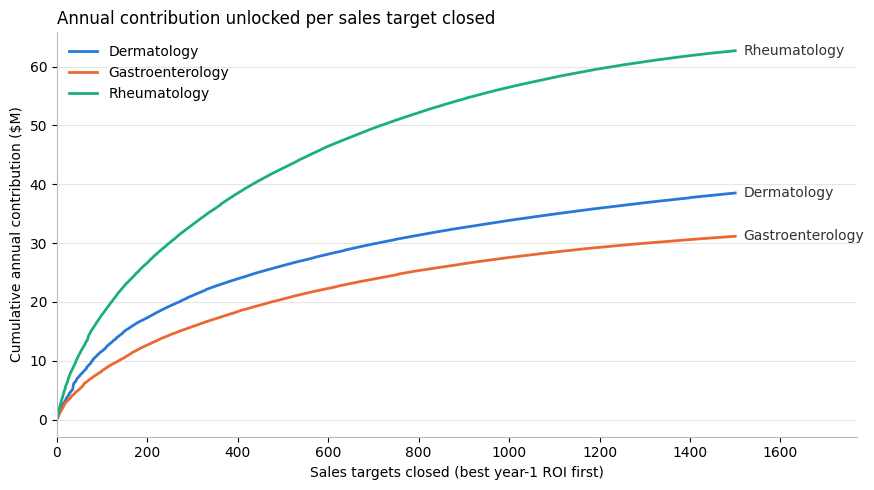

providers  contribution  acquisition_cost  \
n_targets specialty                                                     
50        Dermatology             937  7,420,160.00        484,250.00   
          Gastroenterology       1121  5,196,566.67        530,250.00   
          Rheumatology            430 11,158,980.83        357,500.00   
100       Dermatology            1665 11,647,735.00        916,250.00   
          Gastroenterology       2055  8,329,041.67      1,013,750.00   
          Rheumatology            847 17,854,472.50        711,750.00   
250       Dermatology            3110 19,301,266.67      2,027,500.00   
          Gastroenterology       4035 14,392,966.67      2,258,750.00   
          Rheumatology           1676 30,110,604.17      1,669,000.00   
500       Dermatology            4560 26,178,830.00      3,640,000.00   
          Gastroenterology       6283 20,488,634.17      4,070,750.00   
          Rheumatology           2637 42,750,450.83      3,159,250.00   

                            share_of_specialty_contribution  payback_months  
n_targets specialty                                                          
50        Dermatology                                  0.16            0.78  
          Gastroenterology                             0.15            1.22  
          Rheumatology                                 0.17            0.38  
100       Dermatology                                  0.24            0.94  
          Gastroenterology                             0.24            1.46  
          Rheumatology                                 0.28            0.48  
250       Dermatology                                  0.40            1.26  
          Gastroenterology                             0.42            1.88  
          Rheumatology                                 0.47            0.67  
500       Dermatology                                  0.55            1.67  
          Gastroenterology                             0.60            2.38  
          Rheumatology                                 0.66            0.89

In [24]:
curve = fg.capture_curve(targets, A)

COLORS = {"Dermatology": "#2a78d6", "Gastroenterology": "#eb6834", "Rheumatology": "#1baf7a"}
X_MAX = 1500

fig, ax = plt.subplots(figsize=(9, 5))
for spec, c in curve.groupby("specialty"):
    c = c[c["cum_n_sales_targets"] <= X_MAX]
    ax.plot(c["cum_n_sales_targets"], c["cum_contribution"] / 1e6,
            color=COLORS[spec], linewidth=2, label=spec)
    ax.annotate(spec, (c["cum_n_sales_targets"].iloc[-1], c["cum_contribution"].iloc[-1] / 1e6),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=10, color="#333333")
ax.set_xlabel("Sales targets closed (best year-1 ROI first)")
ax.set_ylabel("Cumulative annual contribution ($M)")
ax.set_title("Annual contribution unlocked per sales target closed", loc="left", fontsize=12)
ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#bbbbbb")
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(0, X_MAX * 1.18)
plt.tight_layout()
plt.show()

fg.at_budget(curve, [50, 100, 250, 500])

## 9. Sensitivity: does the recommendation survive the assumptions?

Each table varies one assumption and shows which specialty leads. If the leader never changes across a
plausible range, the recommendation is robust to that assumption.

In [25]:
sens = {
    "ops_hourly_cost (contribution per sales target)":
        fg.sensitivity(segments, "ops_hourly_cost", [25, 40, 60, 80], A),
    "minutes_biologic (contribution per sales target)":
        fg.sensitivity(segments, "minutes_biologic", [30, 60, 90], A),
    "price_biologic (contribution per sales target)":
        fg.sensitivity(segments, "price_biologic", [100, 200, 300], A),
    "service_other_scripts (contribution per sales target)":
        fg.sensitivity(segments, "service_other_scripts", [True, False], A),
    "biologic_definition (contribution per sales target)":
        fg.sensitivity(segments, "biologic_definition", ["base", "sensitivity"], A),
    "cost_per_sales_target (payback months)":
        fg.sensitivity(segments, "cost_per_sales_target", [1000, 5000, 20000], A, metric="payback_months"),
}
for name, table in sens.items():
    print(name)
    display(table)

ops_hourly_cost (contribution per sales target)


specialty,Dermatology,Gastroenterology,Rheumatology,leader
ops_hourly_cost,,,,
25,"9,948.58","12,366.08","31,531.14",Rheumatology
40,"7,701.20","9,017.78","26,971.75",Rheumatology
60,"4,704.69","4,553.38","20,892.56",Rheumatology
80,"1,708.18",88.97,"14,813.37",Rheumatology


minutes_biologic (contribution per sales target)


specialty,Dermatology,Gastroenterology,Rheumatology,leader
minutes_biologic,,,,
30,"7,701.20","9,017.78","26,971.75",Rheumatology
60,"7,147.70","8,482.09","24,513.80",Rheumatology
90,"6,594.21","7,946.40","22,055.85",Rheumatology


price_biologic (contribution per sales target)


...

specialty,Dermatology,Gastroenterology,Rheumatology,leader
service_other_scripts,,,,
True,"7,701.20","9,017.78","26,971.75",Rheumatology
False,"4,981.44","4,821.22","22,121.53",Rheumatology


biologic_definition (contribution per sales target)


specialty,Dermatology,Gastroenterology,Rheumatology,leader
biologic_definition,,,,
base,"7,701.20","9,017.78","26,971.75",Rheumatology
sensitivity,"8,074.04","9,307.35","29,097.47",Rheumatology


cost_per_sales_target (payback months)


specialty,Dermatology,Gastroenterology,Rheumatology,leader
cost_per_sales_target,,,,
1000,2.46,2.71,0.71,Rheumatology
5000,8.69,8.04,2.49,Rheumatology
20000,32.07,28.00,9.17,Rheumatology


## 9b. New vs continuing patients

Manufacturers pay for patients **starting** therapy: a new biologic patient is a new revenue stream for them,
while a continuing patient is a re-authorization of one they already have. The cost model above treats both
the same (one authorization per patient per year), so this checks whether the ranking hides a difference
in the kind of volume each specialty brings.

- `*_new_share`: new patient-drug pairs ÷ all pairs (`npi_drug_newpatients` ÷ `npi_drug_patients`).
- `new_biologic_per_target`: new biologic pairs per sales target, i.e. how many new starts one deal reaches.
- Volumes are before `capture_rate`. Internal Medicine is shown as a baseline.


In [26]:
new_mix = fg.new_patient_mix(segments, fg.CANDIDATES + ["Internal Medicine"])
new_mix[["providers", "sales_targets", "biologic_new_pairs", "biologic_new_share", "other_new_share",
         "total_new_share", "new_biologic_per_provider", "new_biologic_per_target"]]

,providers,sales_targets,biologic_new_pairs,biologic_new_share,other_new_share,total_new_share,new_biologic_per_provider,new_biologic_per_target
specialty,,,,,,,,
Rheumatology,5780,2393,306195,0.26,0.37,0.36,52.97,127.95
Dermatology,14370,6198,215238,0.31,0.65,0.64,14.98,34.73
Gastroenterology,15843,3811,127392,0.31,0.54,0.54,8.04,33.43
Internal Medicine,114671,28078,46156,0.26,0.42,0.42,0.40,1.64


In [27]:
# Within the recommended specialty: where do the new biologic starts sit?
fg.new_patient_mix(segments, [FOCUS] if "FOCUS" in dir() else ["Rheumatology"], by="institution_size")[
    ["providers", "sales_targets", "biologic_new_share", "new_biologic_per_target", "share_of_new_biologic"]]

,providers,sales_targets,biologic_new_share,new_biologic_per_target,share_of_new_biologic
institution_size,,,,,
5. System (500+),2536,401,0.25,329.80,0.43
2. Mid (6-25),271,115,0.29,163.39,0.06
4. Very large (101-500),1896,1012,0.26,107.96,0.36
3. Large (26-100),394,272,0.26,81.54,0.07
1. Small (1-5),343,253,0.27,81.30,0.07
0. Unaffiliated,340,340,0.29,9.26,0.01


**Read-out.** Rheumatology has the *lowest* new-patient share of the three (about 26% of biologic pairs vs 31%
for Derm and GI), so more of its book is continuing patients on re-authorization. But it still reaches the most new
biologic starts per sales target (≈128 vs ≈35 Derm and ≈33 GI), because its biologic volume is so much larger. The
recommendation holds on the metric manufacturers care about most. The trade-off is that Rheum's value leans more
on recurring re-authorizations, which is steady volume for Forus but less differentiated for pharma partners.

Within Rheumatology, new-patient share is flat across institution sizes (≈26–29%), and health systems (500+)
hold 43% of new biologic starts (≈330 per target), so Tier 1 in the targeting plan is also where the new starts are.


## 10. Targeting (Part 1b)

Set `FOCUS` to the recommended specialty. Each table is sorted by year-1 ROI (contribution ÷ acquisition cost).

- **By institution type and by size:** where the specialty's value sits. `firm_group` pools the small facility
  types (ASCs, FQHCs, home health, etc.) into "Other facility".
- **Type × size:** the segment grid the sales motion is planned on.
- **Ranked targets:** the working list. `champion_*` columns name each target's highest-volume biologic
  prescriber (the first contact inside the institution) and the share of the target's biologic volume they
  carry. IDs are anonymized; in practice `target_id` and `champion_npi` join to institution and provider
  names in the CRM.

In [28]:
FOCUS = "Rheumatology"
COLS = ["providers", "sales_targets", "providers_per_target", "biologic_pairs_per_provider",
        "contribution_per_target", "share_of_contribution", "roi_year1"]

print(f"{FOCUS}: by institution type")
display(fg.breakdown(segments, FOCUS, "firm_group", A)[COLS])

print(f"{FOCUS}: by institution size")
display(fg.breakdown(segments, FOCUS, "institution_size", A)[COLS])

print(f"{FOCUS}: type x size (segments with 10+ providers)")
grid = fg.breakdown(segments, FOCUS, ["firm_group", "institution_size"], A)
display(grid[grid["providers"] >= 10][COLS])

Rheumatology: by institution type


,providers,sales_targets,providers_per_target,biologic_pairs_per_provider,contribution_per_target,share_of_contribution,roi_year1
firm_group,,,,,,,
Hospital,4442,1520,2.92,212.92,"33,903.10",0.80,5.92
Physician Group,944,486,1.94,222.91,"24,369.62",0.18,4.44
Other facility,54,47,1.15,174.91,"11,706.42",0.01,2.21
Unaffiliated,340,340,1.00,31.53,"1,814.25",0.01,0.35


Rheumatology: by institution size


,providers,sales_targets,providers_per_target,biologic_pairs_per_provider,contribution_per_target,share_of_contribution,roi_year1
institution_size,,,,,,,
5. System (500+),2536,401,6.32,204.61,"68,945.52",0.43,10.48
2. Mid (6-25),271,115,2.36,240.25,"31,673.05",0.06,5.67
4. Very large (101-500),1896,1012,1.87,222.78,"23,274.64",0.36,4.26
3. Large (26-100),394,272,1.45,213.72,"17,364.90",0.07,3.24
1. Small (1-5),343,253,1.36,218.83,"17,232.44",0.07,3.23
0. Unaffiliated,340,340,1.00,31.53,"1,814.25",0.01,0.35


Rheumatology: type x size (segments with 10+ providers)


providers  sales_targets  \
firm_group      institution_size                                    
Hospital        5. System (500+)              2456            377   
Physician Group 2. Mid (6-25)                  229             76   
                5. System (500+)                80             24   
                3. Large (26-100)              143             65   
Hospital        4. Very large (101-500)       1728            928   
Physician Group 4. Very large (101-500)        162             81   
                1. Small (1-5)                 330            240   
Other facility  2. Mid (6-25)                   19             17   
Hospital        3. Large (26-100)              233            191   
                2. Mid (6-25)                   23             22   
Other facility  3. Large (26-100)               18             16   
                1. Small (1-5)                  11             11   
Unaffiliated    0. Unaffiliated                340            340   

                                         providers_per_target  \
firm_group      institution_size                                
Hospital        5. System (500+)                         6.51   
Physician Group 2. Mid (6-25)                            3.01   
                5. System (500+)                         3.33   
                3. Large (26-100)                        2.20   
Hospital        4. Very large (101-500)                  1.86   
Physician Group 4. Very large (101-500)                  2.00   
                1. Small (1-5)                           1.38   
Other facility  2. Mid (6-25)                            1.12   
Hospital        3. Large (26-100)                        1.22   
                2. Mid (6-25)                            1.05   
Other facility  3. Large (26-100)                        1.12   
                1. Small (1-5)                           1.00   
Unaffiliated    0. Unaffiliated                          1.00   

                                         biologic_pairs_per_provider  \
firm_group      institution_size                                       
Hospital        5. System (500+)                              205.12   
Physician Group 2. Mid (6-25)                                 247.59   
                5. System (500+)                              189.07   
                3. Large (26-100)                             236.12   
Hospital        4. Very large (101-500)                       225.71   
Physician Group 4. Very large (101-500)                       194.68   
                1. Small (1-5)                                222.11   
Other facility  2. Mid (6-25)                                 254.89   
Hospital        3. Large (26-100)                             205.09   
                2. Mid (6-25)                                 155.09   
Other facility  3. Large (26-100)                             147.44   
                1. Small (1-5)                                102.00   
Unaffiliated    0. Unaffiliated                                31.53   

                                         contribution_per_target  \
firm_group      institution_size                                   
Hospital        5. System (500+)                       71,237.95   
Physician Group 2. Mid (6-25)                          41,597.61   
                5. System (500+)                       32,935.28   
                3. Large (26-100)                      28,754.99   
Hospital        4. Very large (101-500)                23,406.55   
Physician Group 4. Very large (101-500)                22,055.44   
                1. Small (1-5)                         17,650.85   
Other facility  2. Mid (6-25)                          15,638.04   
Hospital        3. Large (26-100)                      14,141.16   
                2. Mid (6-25)                           9,778.90   
Other facility  3. Large (26-100)                       9,576.04   
                1. Small (1-5)                          7,724.70

In [29]:
ranked = fg.rank_targets(targets, FOCUS, A, top=25)
ranked

,target_id,firm_group,firm_type,institution_size,region,n_providers,n_biologic_prescribers,biologic_pairs,other_pairs,top_biologic_brand,champion_npi,champion_biologic_pairs,champion_share_of_biologic,champion_top_brand,contribution,acquisition_cost,roi_year1
0,2035,Hospital,Hospital,5. System (500+),Northeast,7,7,8722,40750,humira,1338913690619998115,1950,0.22,humira,"426,448.33","6,750.00",63.18
1,4039,Hospital,Hospital,5. System (500+),West,5,4,7336,72220,humira,2149694842224577326,3313,0.45,humira,"390,303.33","6,250.00",62.45
2,550300,Physician Group,Physician Group,5. System (500+),Northeast,6,6,6102,29199,enbrel,-803255247938653336,1295,0.21,enbrel,"298,922.50","6,500.00",45.99
3,732191,Physician Group,Physician Group,3. Large (26-100),Southeast,12,12,7139,35973,humira,-756866119804784309,1007,0.14,humira,"351,232.50","8,000.00",43.90
4,1175,Hospital,Hospital,5. System (500+),Northeast,13,13,7239,41690,humira,8953670105134963365,1383,0.19,humira,"360,496.67","8,250.00",43.70
5,2111,Hospital,Hospital,5. System (500+),Southeast,8,8,6260,21662,humira,3944399659130075200,1721,0.27,humira,"299,751.67","7,000.00",42.82
6,3701,Hospital,Hospital,5. System (500+),Southeast,8,8,5698,33413,humira,-3722655204736458721,1361,0.24,humira,"284,254.17","7,000.00",40.61
7,2034,Hospital,Hospital,4. Very large (101-500),West,3,3,4921,9020,humira,16949293256798325,2397,0.49,humira,"228,961.67","5,750.00",39.82
8,596,Hospital,Hospital,5. System (500+),Southeast,6,6,5268,17590,humira,5615948166723571983,1484,0.28,humira,"251,718.33","6,500.00",38.73
9,1981,Hospital,Hospital,5. System (500+),Southeast,13,13,6649,8784,humira,-8982319899783498819,957,0.14,humira,"306,525.00","8,250.00",37.15


In [30]:
# How dependent is each institution's biologic volume on one prescriber?
# (multi-provider targets with biologic volume only)
multi = targets[(targets["specialty"] == FOCUS) & (targets["n_providers"] > 1) & (targets["biologic_pairs"] > 0)]
multi["champion_share_of_biologic"].describe(percentiles=[0.25, 0.5, 0.75]).to_frame(f"{FOCUS} champion share")

,Rheumatology champion share
count,993.00
mean,0.55
std,0.23
min,0.08
25%,0.38
50%,0.54
75%,0.71
max,1.00


## Notes and caveats

- **Units.** Claims volumes are patient-drug pairs, not scripts and not unique patients.
- **Coverage.** 7,919 NPIs (≈5% of patient-drug pairs) have no NPPES specialty and are excluded from the
  specialty comparison; 12.6% of claims rows carry no institution. Providers with no institution on any claim are treated as
  independent practices (one sales target each); other providers' unaffiliated claims roll up to their primary
  institution.
- **Institution size** uses `affiliation_npi_count`, which counts every provider at the institution, not only
  these specialties.
- **Rheum/GI undercount.** Some rheumatologists and gastroenterologists register in NPPES as Internal Medicine,
  so those specialties' totals are conservative.
- Full list of source-data issues and how each is handled: header of `sql/01_build_analytics_layer.sql`.